In [1]:
# %pip install pandas pyarrow
import pandas as pd
import pyarrow.parquet as pq

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

### Adjust the Config Window

In [ ]:
config_window = 60 # 30, 60, 90

# 1. Prepare PCA input

In [3]:
def prepare_stablecoin_pca_df(df):

    drop_cols = [
        'depeg', 'timeOpen', 'timeClose', 'timeHigh', 'timeLow',
        'open', 'high', 'low', 'close', 'volume', 'marketCap', 'circulatingSupply',
        'depeg_future_1d', 'depeg_future_3d', 'depeg_future_5d', 'depeg_future_7d', 
        'depeg_future_14d', 'depeg_future_30d'
    ]

    pca_df = df.copy()

    # Drop only columns that actually exist
    pca_df = pca_df.drop(columns=[c for c in drop_cols if c in pca_df.columns], errors="ignore")
    
    # Keep only timestamp, symbol and numeric feature columns
    pca_df = pca_df[['timestamp', 'symbol'] + [c for c in pca_df.columns if c not in ['timestamp', 'symbol'] and pd.api.types.is_numeric_dtype(pca_df[c])]]

    # Sort by time
    pca_df = pca_df.sort_values('timestamp').reset_index(drop=True)
    
    return pca_df

## Define pre-event window

In [4]:
def get_real_depeg_days(df_final: pd.DataFrame):
    df = df_final.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.normalize()

    depeg_df = (
        df[df["depeg"] == 1][["timestamp"]]
        .drop_duplicates()
        .sort_values("timestamp")
        .reset_index(drop=True)
    )
    return depeg_df


def build_pre_event_dates(depeg_df, lead_days=7):
    depeg_dates = pd.to_datetime(depeg_df["timestamp"]).dt.normalize().drop_duplicates()
    pre_event_dates = set()

    for d in depeg_dates:
        for k in range(lead_days + 1):   # includes depeg day itself
            pre_event_dates.add((d - pd.Timedelta(days=k)).normalize())

    return pre_event_dates

# 2. Rolling PCA + PC Score Plots

In [5]:
def rolling_pca_scores_normal_only(
    df,
    depeg_df,
    window=config_window,
    n_components=10,
    lead_days=7,
    min_normal_obs=15
):

    pca_df = df.copy()
    pca_df["timestamp"] = pd.to_datetime(pca_df["timestamp"]).dt.normalize()
    pca_df = pca_df.sort_values("timestamp").reset_index(drop=True)

    feature_cols = [c for c in pca_df.columns if c not in ["timestamp", "symbol"]]
    feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(pca_df[c])]

    pre_event_dates = build_pre_event_dates(depeg_df, lead_days=lead_days)

    pc_rows = []
    loadings_dict = {}

    for i in range(window - 1, len(pca_df)):
        window_df = pca_df.iloc[i - window + 1 : i + 1].copy()
        current_row = pca_df.iloc[[i]].copy()
        current_date = current_row["timestamp"].iloc[0]

        # Fit PCA only on normal days inside this rolling window
        train_df = window_df[~window_df["timestamp"].isin(pre_event_dates)].copy()

        if len(train_df) < min_normal_obs:
            row = {"timestamp": current_date, "symbol": current_row["symbol"].iloc[0]}
            for j in range(1, n_components + 1):
                row[f"PC{j}"] = np.nan
            pc_rows.append(row)
            continue

        X_train = train_df[feature_cols].copy()
        X_today = current_row[feature_cols].copy()

        if X_train.isna().any().any() or X_today.isna().any().any():
            row = {"timestamp": current_date, "symbol": current_row["symbol"].iloc[0]}
            for j in range(1, n_components + 1):
                row[f"PC{j}"] = np.nan
            pc_rows.append(row)
            continue

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_today_scaled = scaler.transform(X_today)

        n_comp_use = min(n_components, X_train.shape[0], X_train.shape[1])
        pca = PCA(n_components=n_comp_use)
        pca.fit(X_train_scaled)
        today_scores = pca.transform(X_today_scaled)[0]

        row = {"timestamp": current_date, "symbol": current_row["symbol"].iloc[0]}
        for j in range(1, n_components + 1):
            row[f"PC{j}"] = today_scores[j - 1] if j <= n_comp_use else np.nan
        pc_rows.append(row)

        loadings = pd.DataFrame(
            pca.components_.T,
            index=feature_cols,
            columns=[f"PC{j}" for j in range(1, n_comp_use + 1)]
        )
        loadings_dict[current_date] = loadings

    pc_scores_df = pd.DataFrame(pc_rows)
    return pc_scores_df, loadings_dict

# 3. Z-socre band
- Symmetric threshold band ±m

In [6]:
from matplotlib.pyplot import plot


def plot_pc_zscore_bands(pc_scores_df, pc_cols=None, m = 2.0, baseline_end=None, 
                         hit_df=None, depeg_df=None, window=config_window, plot_pc = None):
    pc_scores_df = pc_scores_df.copy()
    pc_scores_df['timestamp'] = pd.to_datetime(pc_scores_df['timestamp']).dt.normalize()
    baseline_end = pd.to_datetime(baseline_end).normalize()
    
    fig = None

    # fixed baseline
    baseline_mask = pc_scores_df["timestamp"] <= baseline_end

    if baseline_mask.sum() == 0:
        raise ValueError("No baseline observations found before baseline_end.")

    z_df = pc_scores_df[["timestamp"]].copy()

    for col in pc_cols:
        base = pc_scores_df.loc[baseline_mask, col].dropna()
        mu = base.mean()
        sd = base.std(ddof=1)

        if pd.isna(sd) or sd == 0:
            z_df[col] = np.nan
        else:
            z_df[col] = (pc_scores_df[col] - mu) / sd
    
    z_df['symbol'] = pc_scores_df['symbol'].iloc[0]
    
    if plot_pc == True:
        fig, axes = plt.subplots(len(pc_cols), 1, figsize=(15, 2.5 * len(pc_cols)), sharex=True)
        if len(pc_cols) == 1:
            axes = [axes]

        for i, col in enumerate(pc_cols):
            ax = axes[i]
            ymin, ymax = ax.get_ylim()
            ax.set_yticks(np.arange(ymin-10, ymax+10, 1))
            ax.set_ylabel(col, fontsize=16)
            

            ax.plot(z_df["timestamp"], z_df[col], linewidth=1.2)

            # bands
            ax.axhline(+m, linestyle="--", linewidth=1)
            ax.axhline(-m, linestyle="--", linewidth=1)
            ax.axhline(0, linestyle=":", linewidth=1)

            # optional: highlight hits
            if hit_df is not None and not hit_df.empty:
                pc_hits = hit_df[hit_df["PC"] == col]
                if not pc_hits.empty:
                    hit_dates = pd.to_datetime(pc_hits["hit_date"])
                    hit_vals = z_df.loc[z_df["timestamp"].isin(hit_dates), ["timestamp", col]]
                    ax.scatter(hit_vals["timestamp"], hit_vals[col], s=30)

            ax.set_ylabel(col)
            
            # overlay true depeg days
            if depeg_df is not None and not depeg_df.empty:
                depeg_dates = pd.to_datetime(depeg_df["timestamp"])
                depeg_vals = z_df.loc[z_df["timestamp"].isin(depeg_dates), ["timestamp", col]]
                ax.scatter(depeg_vals["timestamp"], depeg_vals[col], marker="x", s=50, zorder=5)
                

        axes[0].set_title(f"Rolling-window z-scores (min_window={config_window}, last-day coordinates) with ±{m}σ bands for {pc_scores_df['symbol'].iloc[0]}",
                        fontsize = 20)
        axes[-1].set_xlabel("Date")
        
        plt.tight_layout()
        plt.show()
    

    return z_df, fig

In [7]:
def plot_pc_zscore_bands_upto(pc_scores_df, pc_cols=None, m=2.0, baseline_end=None, 
                         hit_df=None, depeg_df=None, window=config_window, plot_pc=None,
                         plot_start_date=None,
                         plot_end_date=None):

    pc_scores_df = pc_scores_df.copy()
    pc_scores_df['timestamp'] = pd.to_datetime(pc_scores_df['timestamp']).dt.normalize()
    baseline_end = pd.to_datetime(baseline_end).normalize()
    
    fig = None
    
    if plot_end_date is not None:
        plot_end_date = pd.to_datetime(plot_end_date).normalize()

    if plot_start_date is not None:
        plot_start_date = pd.to_datetime(plot_start_date).normalize()

    # baseline
    baseline_mask = pc_scores_df["timestamp"] <= baseline_end
    if baseline_mask.sum() == 0:
        raise ValueError("No baseline observations found before baseline_end.")

    z_df = pc_scores_df[["timestamp"]].copy()

    for col in pc_cols:
        base = pc_scores_df.loc[baseline_mask, col].dropna()
        mu = base.mean()
        sd = base.std(ddof=1)

        if pd.isna(sd) or sd == 0:
            z_df[col] = np.nan
        else:
            z_df[col] = (pc_scores_df[col] - mu) / sd

    z_df['symbol'] = pc_scores_df['symbol'].iloc[0]

    # ✅ FILTER HERE
    if plot_start_date is not None:
        z_df = z_df[z_df["timestamp"] >= plot_start_date]
    if plot_end_date is not None:
        z_df = z_df[z_df["timestamp"] <= plot_end_date]

    if plot_pc:
        fig, axes = plt.subplots(len(pc_cols), 1, figsize=(10, 2.5 * len(pc_cols)), sharex=True)
        if len(pc_cols) == 1:
            axes = [axes]

        for i, col in enumerate(pc_cols):
            ax = axes[i]

            ax.plot(z_df["timestamp"], z_df[col], linewidth=1.2)

            # bands
            ax.axhline(+m, linestyle="--", linewidth=1)
            ax.axhline(-m, linestyle="--", linewidth=1)
            ax.axhline(0, linestyle=":", linewidth=1)

            # hits
            if hit_df is not None and not hit_df.empty:
                pc_hits = hit_df[hit_df["PC"] == col]
                hit_dates = pd.to_datetime(pc_hits["hit_date"])
                hit_dates = hit_dates[hit_dates <= plot_end_date]  # ✅ filter hits
                if plot_start_date is not None:
                    hit_dates = hit_dates[hit_dates >= plot_start_date]

                hit_vals = z_df.loc[z_df["timestamp"].isin(hit_dates), ["timestamp", col]]
                ax.scatter(hit_vals["timestamp"], hit_vals[col], s=30)

            # depeg
            if depeg_df is not None and not depeg_df.empty:
                depeg_dates = pd.to_datetime(depeg_df["timestamp"])
                depeg_dates = depeg_dates[depeg_dates <= plot_end_date]  # ✅ filter
                if plot_start_date is not None:
                    depeg_dates = depeg_dates[depeg_dates >= plot_start_date]

                depeg_vals = z_df.loc[z_df["timestamp"].isin(depeg_dates), ["timestamp", col]]
                ax.scatter(depeg_vals["timestamp"], depeg_vals[col], marker="x", s=50, zorder=5)

            ax.set_ylabel(col)

        axes[0].set_title(f"Z-scores up to {plot_end_date.date()} for {pc_scores_df['symbol'].iloc[0]}")
        axes[-1].set_xlabel("Date")

        plt.tight_layout()
        plt.show()

    return z_df, fig

# 4. Warnings vs Real Depegs
Same-day warnings do **NOT** count as effective. Only hits with 1 to 7 day lead time are matched.

In [8]:
def get_pc_hits_effective_only(
    z_df,
    m,
    original_df,
    depeg_df,
    pc_cols,
    max_lead_days=7
):

    z_df = z_df.copy()
    z_df["timestamp"] = pd.to_datetime(z_df["timestamp"]).dt.normalize()

    original_df = original_df.copy()
    original_df["timestamp"] = pd.to_datetime(original_df["timestamp"]).dt.normalize()

    depeg_dates = sorted(pd.to_datetime(depeg_df["timestamp"]).dt.normalize().drop_duplicates())

    close_df = (
        original_df[["timestamp", "close"]]
        .drop_duplicates(subset="timestamp")
        .rename(columns={"timestamp": "hit_date", "close": "close_price"})
    )

    hit_records = []

    for pc in pc_cols:
        temp = z_df[["timestamp", pc]].copy()
        temp = temp.rename(columns={"timestamp": "hit_date", pc: "z_score"})
        temp = temp[temp["z_score"].abs() > m].copy()

        if temp.empty:
            continue

        temp["PC"] = pc
        temp = temp.merge(close_df, on="hit_date", how="left")

        for _, row in temp.iterrows():
            hit_date = row["hit_date"]

            valid_depegs = [
                d for d in depeg_dates
                if 1 <= (d - hit_date).days <= max_lead_days
            ]

            if len(valid_depegs) > 0:
                nearest_depeg = min(valid_depegs)
                row["matched_depeg_date"] = nearest_depeg
                row["lead_time_days"] = (nearest_depeg - hit_date).days
                row["is_matched"] = True
            else:
                row["matched_depeg_date"] = pd.NaT
                row["lead_time_days"] = np.nan
                row["is_matched"] = False

            hit_records.append(row)

    if len(hit_records) == 0:
        return pd.DataFrame(columns=[
            "hit_date", "PC", "z_score", "close_price",
            "matched_depeg_date", "lead_time_days", "is_matched"
        ])

    hit_df = pd.DataFrame(hit_records).sort_values(["hit_date", "PC"]).reset_index(drop=True)
    return hit_df

For matched hits only, store the matched PC and its dominant variables/loadings on that hit date.

In [9]:
def extract_matched_pc_profiles(
    hit_df,
    loadings_dict,
    top_n=5
):

    hit_df = hit_df.copy()
    hit_df["hit_date"] = pd.to_datetime(hit_df["hit_date"]).dt.normalize()

    matched = hit_df[hit_df["is_matched"]].copy()
    profile_rows = []

    for _, row in matched.iterrows():
        hit_date = row["hit_date"]
        pc = row["PC"]

        if hit_date not in loadings_dict:
            continue

        loadings = loadings_dict[hit_date]
        if pc not in loadings.columns:
            continue

        pc_loadings = loadings[pc].dropna().sort_values(key=np.abs, ascending=False).head(top_n)

        out = {
            "hit_date": hit_date,
            "matched_depeg_date": row["matched_depeg_date"],
            "lead_time_days": row["lead_time_days"],
            "PC": pc,
            "z_score": row["z_score"]
        }

        for k, (var, val) in enumerate(pc_loadings.items(), start=1):
            out[f"top{k}_var"] = var
            out[f"top{k}_loading"] = val

        profile_rows.append(out)

    return pd.DataFrame(profile_rows)

Summarize which variables recur most often among matched PCs

In [10]:
def summarize_recurring_pc_types(matched_pc_profiles, top_k_vars=3):
    
    rows = []

    for _, r in matched_pc_profiles.iterrows():
        for k in range(1, top_k_vars + 1):
            var_col = f"top{k}_var"
            if var_col in matched_pc_profiles.columns and pd.notna(r.get(var_col)):
                rows.append({
                    "PC": r["PC"],
                    "variable": r[var_col],
                    "matched_depeg_date": r["matched_depeg_date"]
                })

    if len(rows) == 0:
        return pd.DataFrame(columns=["variable", "count"])

    out = pd.DataFrame(rows)
    summary = (
        out.groupby("variable")
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )
    return summary

# 4. Evaluation

In [11]:
def summarize_pc_hits(
    hit_df,
    z_df,
    depeg_df,
    pc_cols,
    max_lead_days=7,
    include_no_lead_time=True
):
    z_df = z_df.copy()
    z_df["timestamp"] = pd.to_datetime(z_df["timestamp"]).dt.normalize()

    depeg_df = depeg_df.copy()
    depeg_df["timestamp"] = pd.to_datetime(depeg_df["timestamp"]).dt.normalize()

    hit_df = hit_df.copy()
    hit_df["hit_date"] = pd.to_datetime(hit_df["hit_date"]).dt.normalize()
    hit_df["matched_depeg_date"] = pd.to_datetime(hit_df["matched_depeg_date"]).dt.normalize()

    depeg_dates = sorted(depeg_df["timestamp"].drop_duplicates())
    depeg_set = set(depeg_dates)

    all_dates = set(z_df["timestamp"].drop_duplicates())
    non_depeg_dates = all_dates - depeg_set

    summary_rows = []

    for pc in pc_cols:
        pc_hits = hit_df[hit_df["PC"] == pc].copy()
        hit_dates = set(pc_hits["hit_date"])

        matched_hits = pc_hits[pc_hits["is_matched"]].copy()

        if not matched_hits.empty:
            matched_hits["lead_time"] = (
                matched_hits["matched_depeg_date"] - matched_hits["hit_date"]
            ).dt.days

            if include_no_lead_time:
                matched_hits = matched_hits[
                    (matched_hits["lead_time"] >= 0) &
                    (matched_hits["lead_time"] <= max_lead_days)
                ]
            else:
                matched_hits = matched_hits[
                    (matched_hits["lead_time"] >= 1) &
                    (matched_hits["lead_time"] <= max_lead_days)
                ]

        if not matched_hits.empty:
            # earliest warning day for each matched depeg date
            earliest_hits = (
                matched_hits
                .sort_values("hit_date")
                .groupby("matched_depeg_date", as_index=False)
                .first()
            )

            avg_lead_time_matched = earliest_hits["lead_time"].mean()
            first_match_days = earliest_hits["hit_date"].sort_values().tolist()
            matched_depeg_days = earliest_hits["matched_depeg_date"].sort_values().tolist()
            matched_hit_dates = set(matched_hits["hit_date"])
        else:
            avg_lead_time_matched = np.nan
            first_match_days = []
            matched_depeg_days = []
            matched_hit_dates = set()

        covered_depeg_days = set()
        for d in depeg_dates:
            if include_no_lead_time:
                valid_hits = [h for h in hit_dates if h <= d and (d - h).days <= max_lead_days]
            else:
                valid_hits = [h for h in hit_dates if h < d and 1 <= (d - h).days <= max_lead_days]

            if valid_hits:
                covered_depeg_days.add(d)

        tp = len(matched_hit_dates)
        fp = len(hit_dates - matched_hit_dates)
        fn = len(depeg_set - covered_depeg_days)
        tn = len(non_depeg_dates - hit_dates)

        precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        f1 = (
            2 * precision * recall / (precision + recall)
            if pd.notna(precision) and pd.notna(recall) and (precision + recall) > 0
            else np.nan
        )
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

        summary_rows.append({
            "PC": pc,
            "num_hit_days": len(hit_dates),
            "num_real_depeg_days": len(depeg_set),
            "num_matched_days": len(matched_hit_dates),
            "matched_depeg_days": matched_depeg_days,
            "first_match_days": first_match_days,
            "avg_close_price_hit_days": pc_hits["close_price"].mean() if not pc_hits.empty else np.nan,
            "avg_lead_time_matched": avg_lead_time_matched,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "specificity": specificity
        })

    summary_df = (
        pd.DataFrame(summary_rows)
        .sort_values(["num_matched_days", "precision"], ascending=False)
        .reset_index(drop=True)
    )

    return summary_df

# Example Call DAI
## Output
- hit_df_dai
    - all warnings
    - whether they are effective
    - matched depeg date
    - lead time (and same-day hits are not matched)

- matched_pc_profiles_dai (for every effective matched warning)
    - hit date
    - matched depeg date
    - lead time
    - matched PC
    - top loading variables of that PC

- recurring_summary_dai
    - which variables appear most often in matched PCs

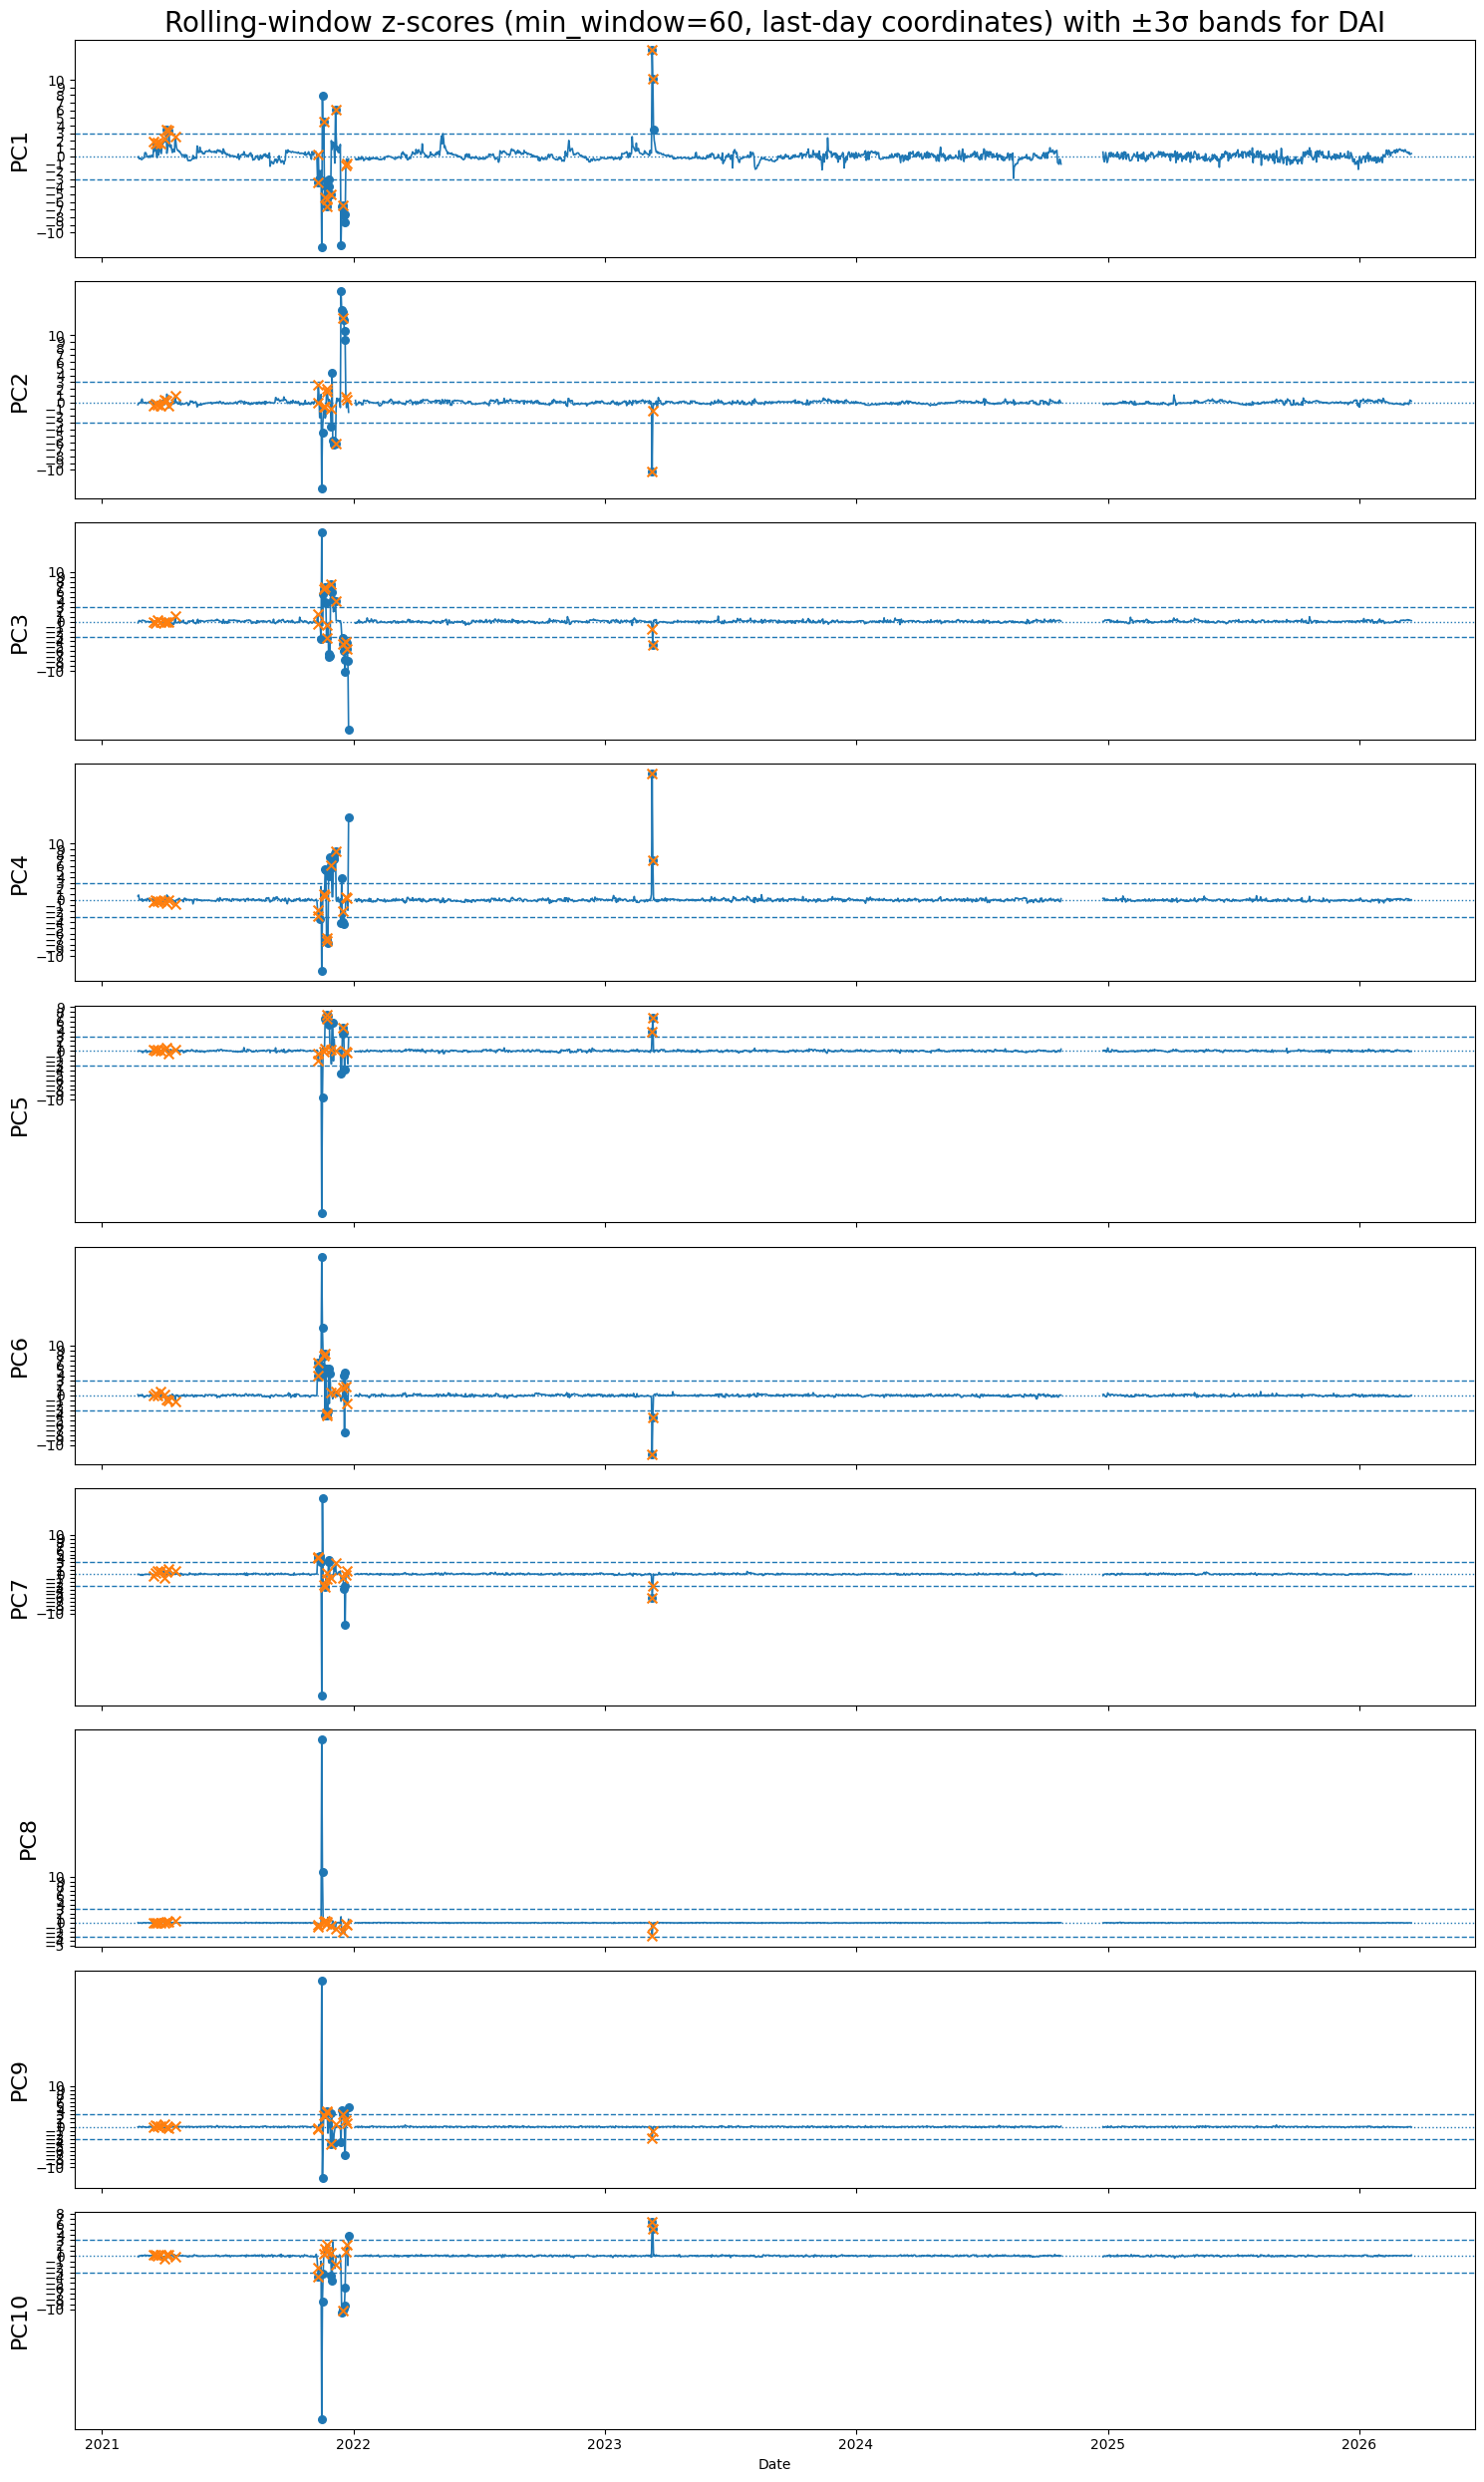

,PC,num_hit_days,num_real_depeg_days,num_matched_days,matched_depeg_days,first_match_days,avg_close_price_hit_days,avg_lead_time_matched,precision,recall,f1_score,specificity
0,PC3,27,23,25,"[2021-11-19 00:00:00, 2021-11-20 00:00:00, 202...","[2021-11-15 00:00:00, 2021-11-19 00:00:00, 202...",1.000814,3.100000,0.925926,0.657895,0.769231,0.998897
1,PC1,27,23,23,"[2021-04-08 00:00:00, 2021-11-11 00:00:00, 202...","[2021-04-04 00:00:00, 2021-11-10 00:00:00, 202...",1.000106,3.363636,0.851852,0.676471,0.754098,0.997801
2,PC4,23,23,21,"[2021-11-19 00:00:00, 2021-11-23 00:00:00, 202...","[2021-11-14 00:00:00, 2021-11-21 00:00:00, 202...",0.999392,3.333333,0.913043,0.636364,0.750000,0.998898
3,PC6,23,23,21,"[2021-11-11 00:00:00, 2021-11-19 00:00:00, 202...","[2021-11-10 00:00:00, 2021-11-12 00:00:00, 202...",0.999377,2.750000,0.913043,0.600000,0.724138,0.998899
4,PC9,17,23,17,"[2021-11-19 00:00:00, 2021-11-23 00:00:00, 202...","[2021-11-16 00:00:00, 2021-11-21 00:00:00, 202...",1.000308,3.500000,1.000000,0.566667,0.723404,1.000000
5,PC5,18,23,17,"[2021-11-19 00:00:00, 2021-11-23 00:00:00, 202...","[2021-11-16 00:00:00, 2021-11-21 00:00:00, 202...",0.998173,3.000000,0.944444,0.566667,0.708333,0.999450
6,PC2,17,23,16,"[2021-11-19 00:00:00, 2021-12-06 00:00:00, 202...","[2021-11-16 00:00:00, 2021-11-30 00:00:00, 202...",0.998417,3.400000,0.941176,0.533333,0.680851,0.999450
7,PC7,15,23,14,"[2021-11-11 00:00:00, 2021-11-19 00:00:00, 202...","[2021-11-10 00:00:00, 2021-11-12 00:00:00, 202...",0.998941,3.000000,0.933333,0.500000,0.651163,0.999451
8,PC10,15,23,13,"[2021-11-19 00:00:00, 2021-12-06 00:00:00, 202...","[2021-11-16 00:00:00, 2021-11-30 00:00:00, 202...",0.997781,3.166667,0.866667,0.500000,0.634146,0.998902
9,PC8,2,23,2,[2021-11-19 00:00:00],[2021-11-16 00:00:00],1.002113,3.000000,1.000000,0.095238,0.173913,1.000000


In [12]:
pc_cols = [f"PC{i}" for i in range(1, 11)]

df_dai_final = pd.read_parquet("../clean_data/dai_final.parquet")
df_dai_pca = prepare_stablecoin_pca_df(df_dai_final)
depeg_df_dai = get_real_depeg_days(df_dai_final)

pc_scores_dai, loadings_dict_dai = rolling_pca_scores_normal_only(
    df=df_dai_pca,
    depeg_df=depeg_df_dai,
    n_components=10,
    lead_days=7,
    min_normal_obs=10
)


# wanrings and hits
z_df_dai = plot_pc_zscore_bands(pc_scores_dai, baseline_end="2026-03-19", m = 3.0,
                     pc_cols=[f"PC{i}" for i in range(1, 11)])[0]

# effective warnings only: exclude same-day hits
hit_df_dai = get_pc_hits_effective_only(
    z_df=z_df_dai,
    m=3,
    original_df=df_dai_final,
    depeg_df=depeg_df_dai,
    pc_cols=pc_cols,
    max_lead_days=7
)

# Compare warnings with actual depeg days
plot_dai = plot_pc_zscore_bands(
    z_df_dai,
    m = 3,
    baseline_end="2026-03-19",
    pc_cols=[f"PC{i}" for i in range(1, 11)],
    hit_df=hit_df_dai,
    depeg_df=depeg_df_dai,
    plot_pc=True
)[1]


# matched PC profiles
matched_pc_profiles_dai = extract_matched_pc_profiles(
    hit_df=hit_df_dai,
    loadings_dict=loadings_dict_dai,
    top_n=5
)

# recurring variable patterns
recurring_summary_dai = summarize_recurring_pc_types(
    matched_pc_profiles_dai,
    top_k_vars=3
)

summary_df_dai = summarize_pc_hits(
    hit_df=hit_df_dai,
    z_df=z_df_dai,
    depeg_df=depeg_df_dai,
    pc_cols=[f"PC{i}" for i in range(1, 11)],
    max_lead_days=7,
    include_no_lead_time=False
)
summary_df_dai.head(10)

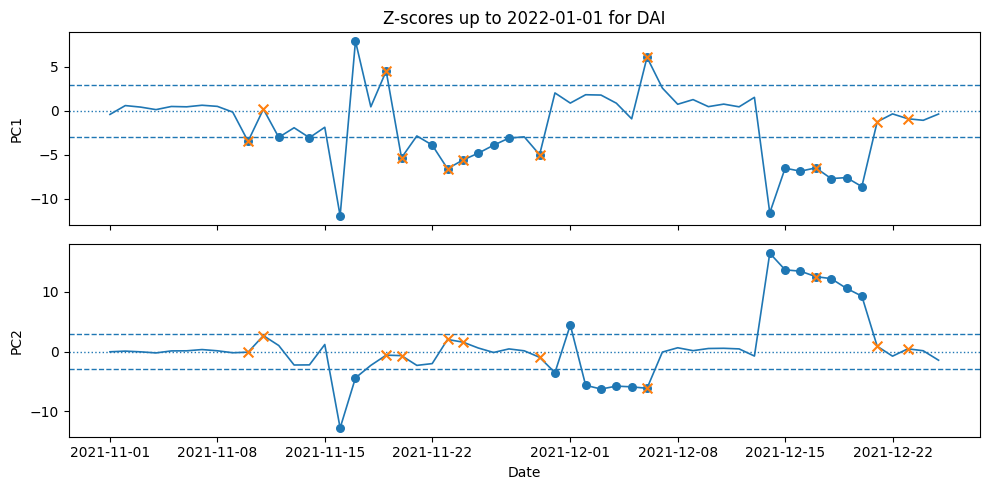

In [13]:
plot_dai = plot_pc_zscore_bands_upto(
    z_df_dai,
    m = 3,
    baseline_end="2026-03-19",
    pc_cols=[f"PC{i}" for i in range(1, 3)],
    hit_df=hit_df_dai,
    depeg_df=depeg_df_dai,
    plot_pc=True,
    plot_start_date = "2021-11-01",
    plot_end_date="2022-01-01"
)[1]

# For USDP

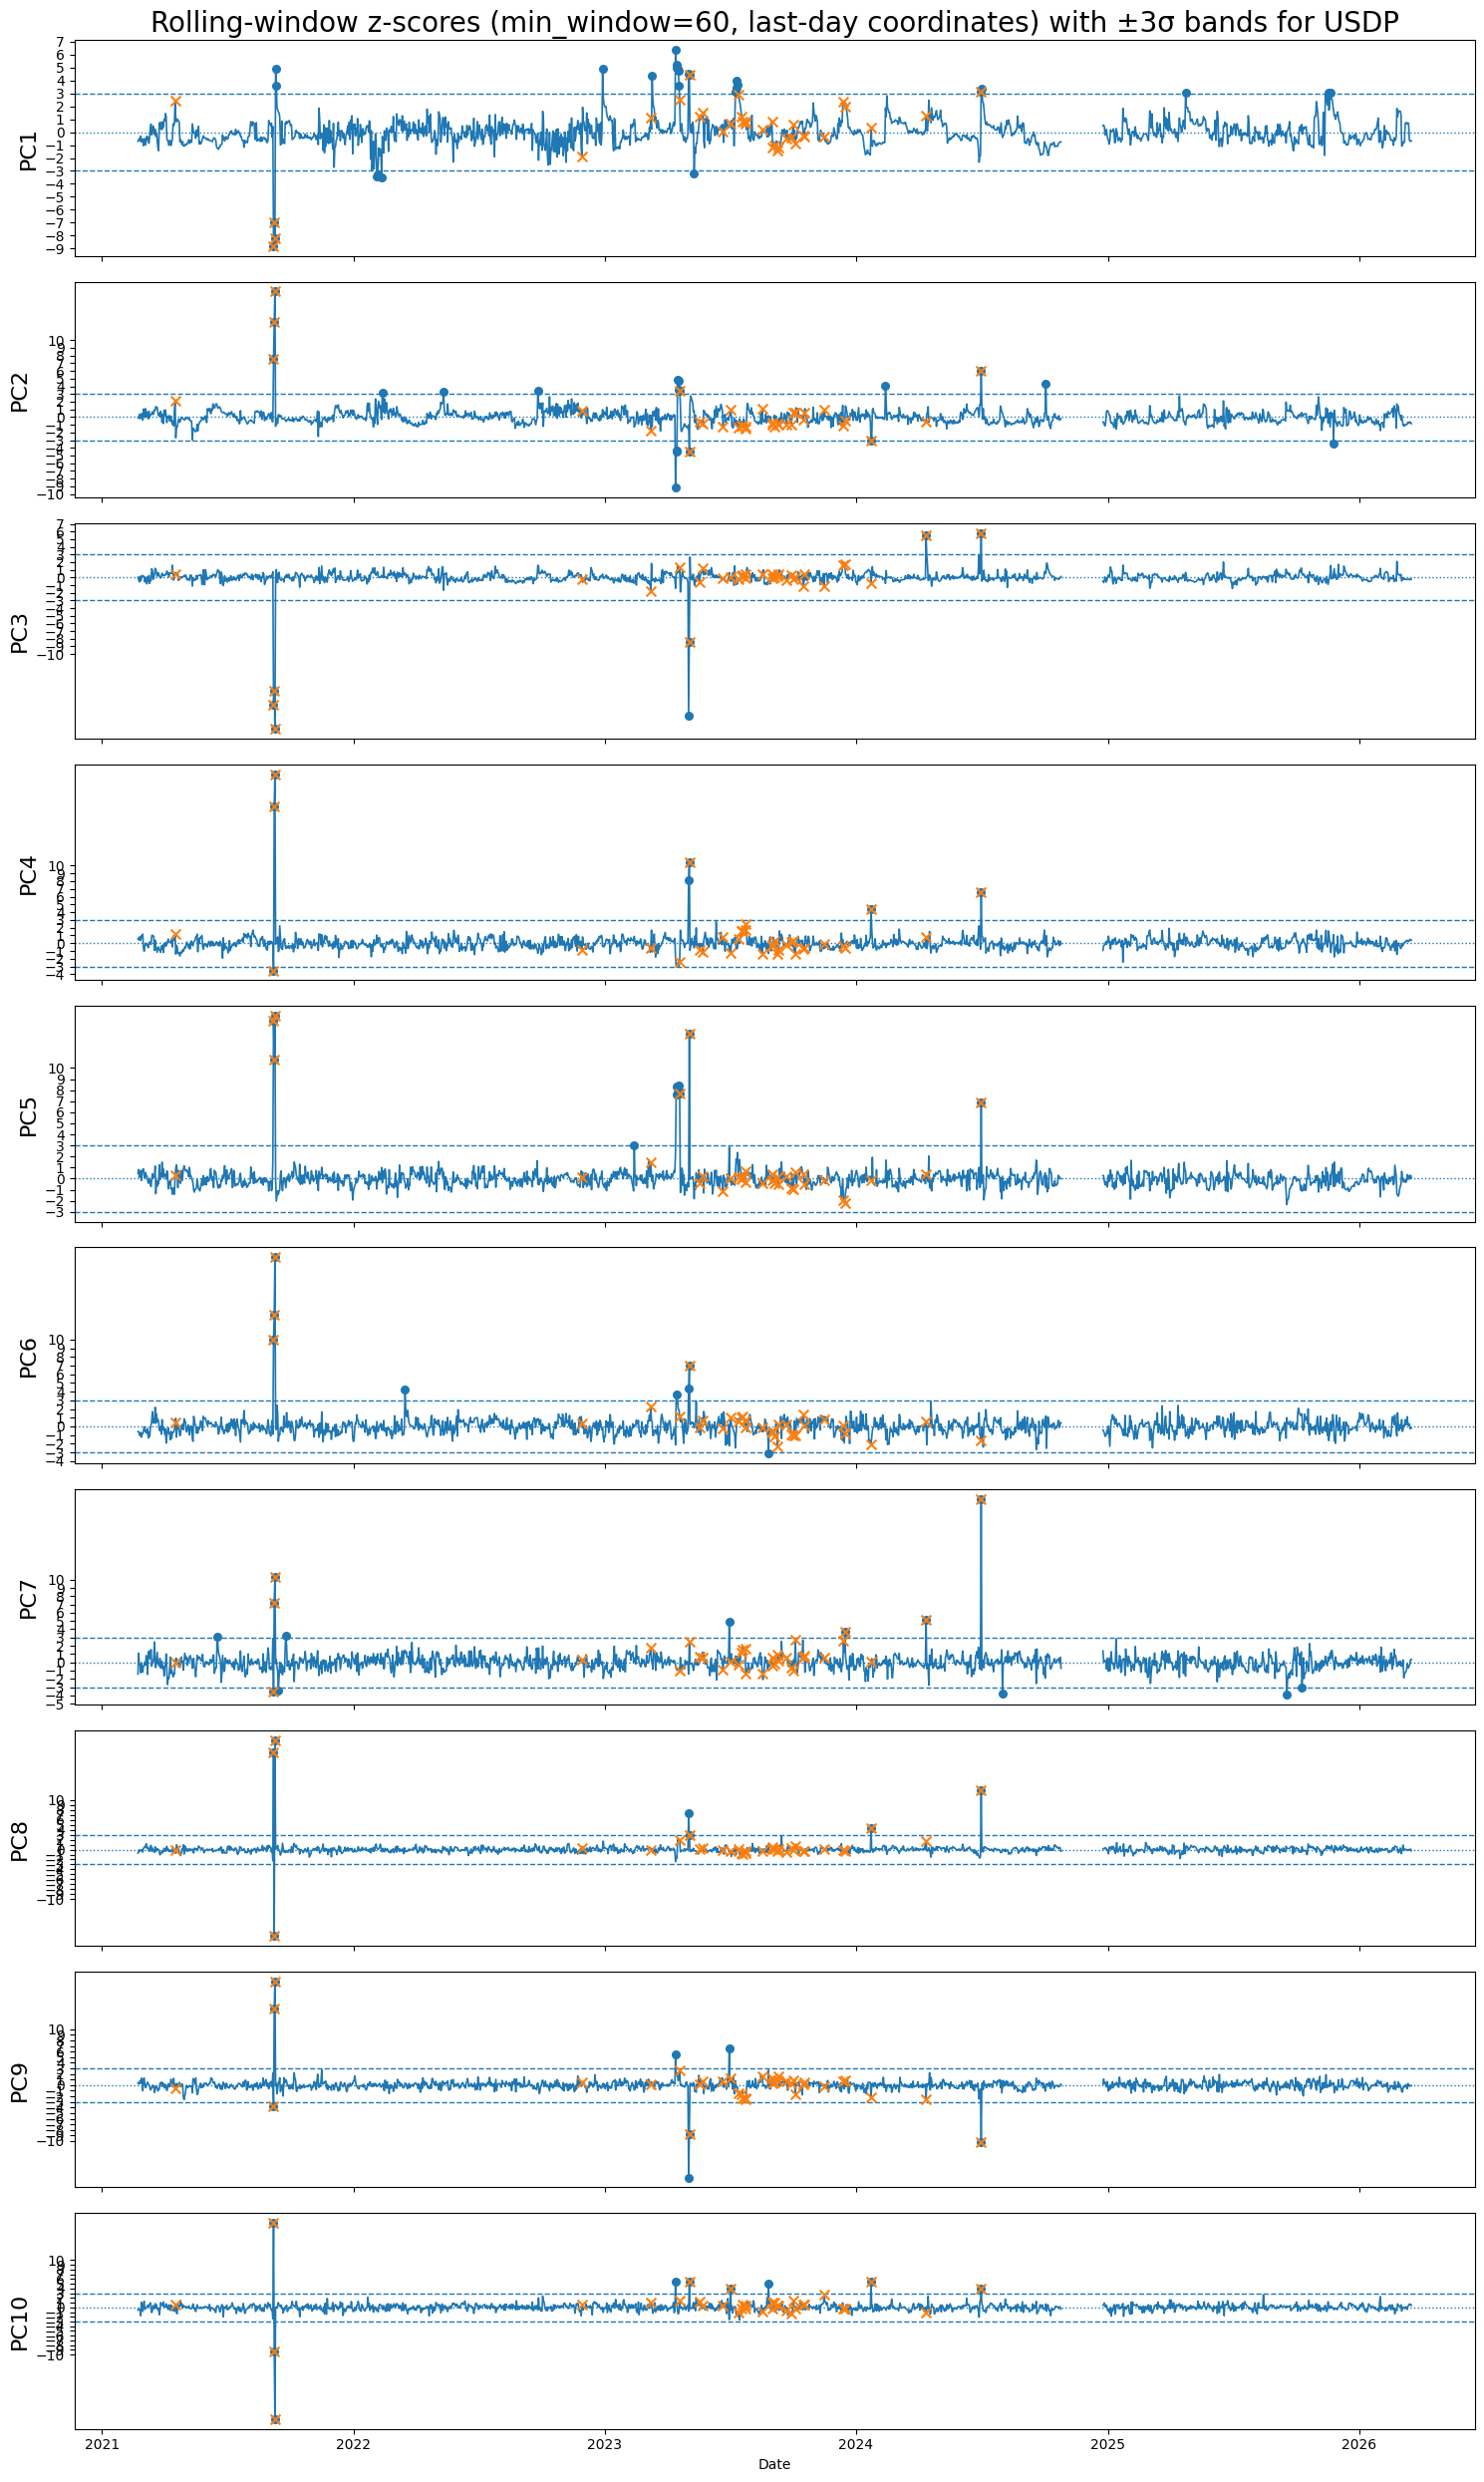

,PC,num_hit_days,num_real_depeg_days,num_matched_days,matched_depeg_days,first_match_days,avg_close_price_hit_days,avg_lead_time_matched,precision,recall,f1_score,specificity
0,PC1,28,35,13,"[2021-09-08 00:00:00, 2021-09-09 00:00:00, 202...","[2021-09-07 00:00:00, 2021-09-08 00:00:00, 202...",0.997368,2.600000,0.464286,0.309524,0.371429,0.991708
1,PC2,19,35,8,"[2021-09-08 00:00:00, 2021-09-09 00:00:00, 202...","[2021-09-07 00:00:00, 2021-09-08 00:00:00, 202...",0.998360,2.666667,0.421053,0.200000,0.271186,0.993943
2,PC5,12,35,7,"[2021-09-08 00:00:00, 2021-09-09 00:00:00, 202...","[2021-09-07 00:00:00, 2021-09-08 00:00:00, 202...",0.997118,2.333333,0.583333,0.179487,0.274510,0.997247
3,PC6,8,35,5,"[2021-09-08 00:00:00, 2021-09-09 00:00:00, 202...","[2021-09-07 00:00:00, 2021-09-08 00:00:00, 202...",0.995651,2.600000,0.625000,0.147059,0.238095,0.998348
4,PC9,8,35,5,"[2021-09-08 00:00:00, 2021-09-09 00:00:00, 202...","[2021-09-07 00:00:00, 2021-09-08 00:00:00, 202...",0.997195,2.200000,0.625000,0.142857,0.232558,0.998349
5,PC10,9,35,4,"[2021-09-08 00:00:00, 2021-09-09 00:00:00, 202...","[2021-09-07 00:00:00, 2021-09-08 00:00:00, 202...",0.997267,3.250000,0.444444,0.117647,0.186047,0.997253
6,PC3,7,35,3,"[2021-09-08 00:00:00, 2021-09-09 00:00:00, 202...","[2021-09-07 00:00:00, 2021-09-08 00:00:00, 202...",0.997744,1.000000,0.428571,0.085714,0.142857,0.997802
7,PC4,7,35,3,"[2021-09-08 00:00:00, 2021-09-09 00:00:00, 202...","[2021-09-07 00:00:00, 2021-09-08 00:00:00, 202...",0.995189,1.000000,0.428571,0.085714,0.142857,0.997802
8,PC8,7,35,3,"[2021-09-08 00:00:00, 2021-09-09 00:00:00, 202...","[2021-09-07 00:00:00, 2021-09-08 00:00:00, 202...",0.995189,1.000000,0.428571,0.085714,0.142857,0.997802
9,PC7,13,35,3,"[2021-09-08 00:00:00, 2021-09-09 00:00:00, 202...","[2021-09-07 00:00:00, 2021-09-08 00:00:00, 202...",0.998973,1.333333,0.230769,0.085714,0.125000,0.994505


In [14]:
pc_cols = [f"PC{i}" for i in range(1, 11)]

df_pax_final = pd.read_parquet("../clean_data/pax_final.parquet")
df_pax_pca = prepare_stablecoin_pca_df(df_pax_final)
depeg_df_pax = get_real_depeg_days(df_pax_final)

pc_scores_pax, loadings_dict_pax = rolling_pca_scores_normal_only(
    df=df_pax_pca,
    depeg_df=depeg_df_pax,
    n_components=10,
    lead_days=7,
    min_normal_obs=10
)

# wanrings and hits
z_df_pax = plot_pc_zscore_bands(pc_scores_pax, baseline_end="2026-03-19", m = 3.0,
                     pc_cols=[f"PC{i}" for i in range(1, 11)])[0]

# effective warnings only: exclude same-day hits
hit_df_pax = get_pc_hits_effective_only(
    z_df=z_df_pax,
    m=3,
    original_df=df_pax_final,
    depeg_df=depeg_df_pax,
    pc_cols=pc_cols,
    max_lead_days=7
)

# Compare warnings with actual depeg days
plot_pax = plot_pc_zscore_bands(
    z_df_pax,
    m = 3,
    baseline_end="2026-03-19",
    pc_cols=[f"PC{i}" for i in range(1, 11)],
    hit_df=hit_df_pax,
    depeg_df=depeg_df_pax,
    plot_pc=True
)[1]

# matched PC profiles
matched_pc_profiles_pax = extract_matched_pc_profiles(
    hit_df=hit_df_pax,
    loadings_dict=loadings_dict_pax,
    top_n=5
)

# recurring variable patterns
recurring_summary_pax = summarize_recurring_pc_types(
    matched_pc_profiles_pax,
    top_k_vars=3
)

summary_df_pax = summarize_pc_hits(
    hit_df=hit_df_pax,
    z_df=z_df_pax,
    depeg_df=depeg_df_pax,
    pc_cols=[f"PC{i}" for i in range(1, 11)],
    max_lead_days=7,
    include_no_lead_time=False
)
summary_df_pax.head(10)

# For USDC

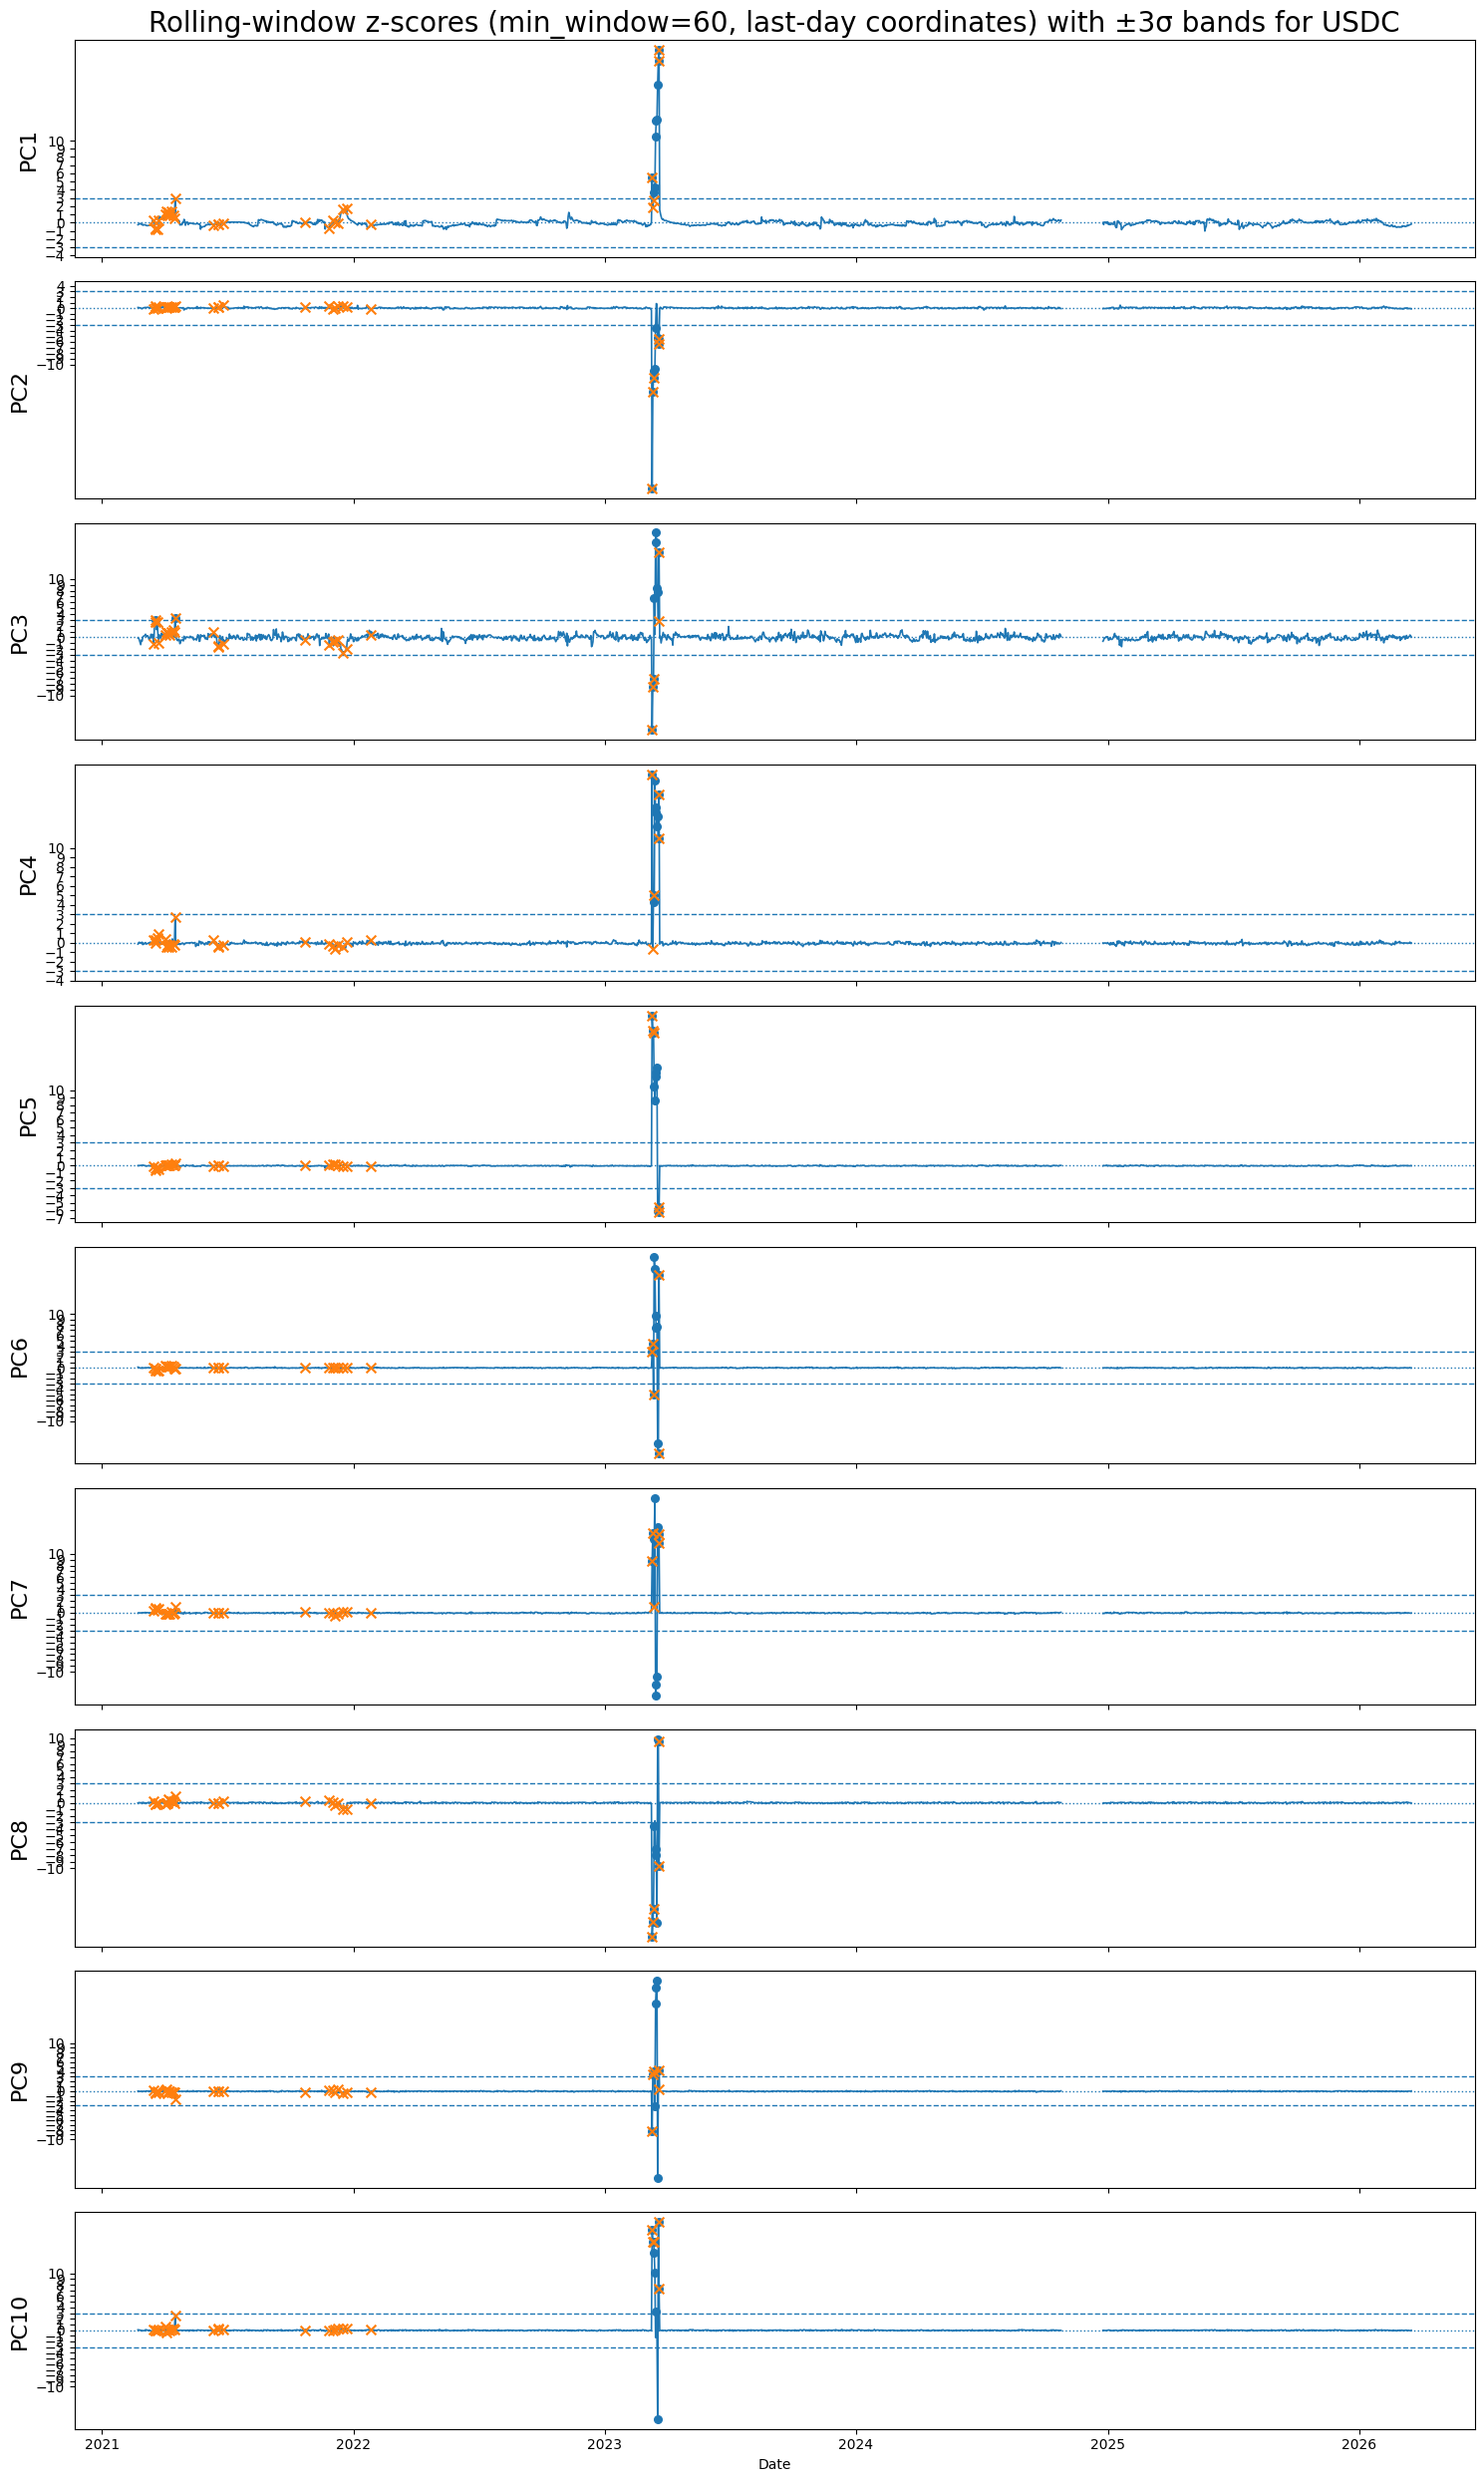

,PC,num_hit_days,num_real_depeg_days,num_matched_days,matched_depeg_days,first_match_days,avg_close_price_hit_days,avg_lead_time_matched,precision,recall,f1_score,specificity
0,PC5,11,32,10,"[2023-03-12 00:00:00, 2023-03-13 00:00:00, 202...","[2023-03-11 00:00:00, 2023-03-12 00:00:00, 202...",0.996158,2.500000,0.909091,0.263158,0.408163,0.999449
1,PC6,11,32,10,"[2023-03-12 00:00:00, 2023-03-13 00:00:00, 202...","[2023-03-11 00:00:00, 2023-03-12 00:00:00, 202...",0.996158,2.500000,0.909091,0.263158,0.408163,0.999449
2,PC4,10,32,9,"[2023-03-12 00:00:00, 2023-03-20 00:00:00, 202...","[2023-03-11 00:00:00, 2023-03-13 00:00:00, 202...",0.996567,3.000000,0.900000,0.243243,0.382979,0.999449
3,PC7,10,32,9,"[2023-03-12 00:00:00, 2023-03-13 00:00:00, 202...","[2023-03-11 00:00:00, 2023-03-12 00:00:00, 202...",0.995879,2.250000,0.900000,0.243243,0.382979,0.999449
4,PC8,10,32,9,"[2023-03-12 00:00:00, 2023-03-13 00:00:00, 202...","[2023-03-11 00:00:00, 2023-03-12 00:00:00, 202...",0.995755,2.500000,0.900000,0.243243,0.382979,0.999450
5,PC3,11,32,9,"[2021-03-20 00:00:00, 2023-03-12 00:00:00, 202...","[2021-03-19 00:00:00, 2023-03-11 00:00:00, 202...",0.997501,2.500000,0.818182,0.264706,0.400000,0.998900
6,PC1,9,32,8,"[2023-03-12 00:00:00, 2023-03-20 00:00:00, 202...","[2023-03-11 00:00:00, 2023-03-14 00:00:00, 202...",0.996302,2.666667,0.888889,0.222222,0.355556,0.999449
7,PC2,9,32,8,"[2023-03-12 00:00:00, 2023-03-13 00:00:00, 202...","[2023-03-11 00:00:00, 2023-03-12 00:00:00, 202...",0.995355,2.500000,0.888889,0.222222,0.355556,0.999450
8,PC9,9,32,8,"[2023-03-12 00:00:00, 2023-03-13 00:00:00, 202...","[2023-03-11 00:00:00, 2023-03-12 00:00:00, 202...",0.995620,3.000000,0.888889,0.222222,0.355556,0.999450
9,PC10,9,32,8,"[2023-03-12 00:00:00, 2023-03-13 00:00:00, 202...","[2023-03-11 00:00:00, 2023-03-12 00:00:00, 202...",0.995364,2.500000,0.888889,0.222222,0.355556,0.999450


In [15]:
pc_cols = [f"PC{i}" for i in range(1, 11)]

df_usdc_final = pd.read_parquet("../clean_data/usdc_final.parquet")
df_usdc_pca = prepare_stablecoin_pca_df(df_usdc_final)
depeg_df_usdc = get_real_depeg_days(df_usdc_final)

pc_scores_usdc, loadings_dict_usdc = rolling_pca_scores_normal_only(
    df=df_usdc_pca,
    depeg_df=depeg_df_usdc,
    n_components=10,
    lead_days=7,
    min_normal_obs=10
)

# wanrings and hits
z_df_usdc = plot_pc_zscore_bands(pc_scores_usdc, baseline_end="2026-03-19", m = 3.0,
                     pc_cols=[f"PC{i}" for i in range(1, 11)])[0]

# effective warnings only: exclude same-day hits
hit_df_usdc = get_pc_hits_effective_only(
    z_df=z_df_usdc,
    m=3,
    original_df=df_usdc_final,
    depeg_df=depeg_df_usdc,
    pc_cols=pc_cols,
    max_lead_days=7
)

# Compare warnings with actual depeg days
plot_usdc = plot_pc_zscore_bands(
    z_df_usdc,
    m = 3,
    baseline_end="2026-03-19",
    pc_cols=[f"PC{i}" for i in range(1, 11)],
    hit_df=hit_df_usdc,
    depeg_df=depeg_df_usdc,
    plot_pc=True
)[1]

# matched PC profiles
matched_pc_profiles_usdc = extract_matched_pc_profiles(
    hit_df=hit_df_usdc,
    loadings_dict=loadings_dict_usdc,
    top_n=5
)

# recurring variable patterns
recurring_summary_usdc = summarize_recurring_pc_types(
    matched_pc_profiles_usdc,
    top_k_vars=3
)

summary_df_usdc = summarize_pc_hits(
    hit_df=hit_df_usdc,
    z_df=z_df_usdc,
    depeg_df=depeg_df_usdc,
    pc_cols=[f"PC{i}" for i in range(1, 11)],
    max_lead_days=7,
    include_no_lead_time=False
)
summary_df_usdc.head(10)

# For USDT

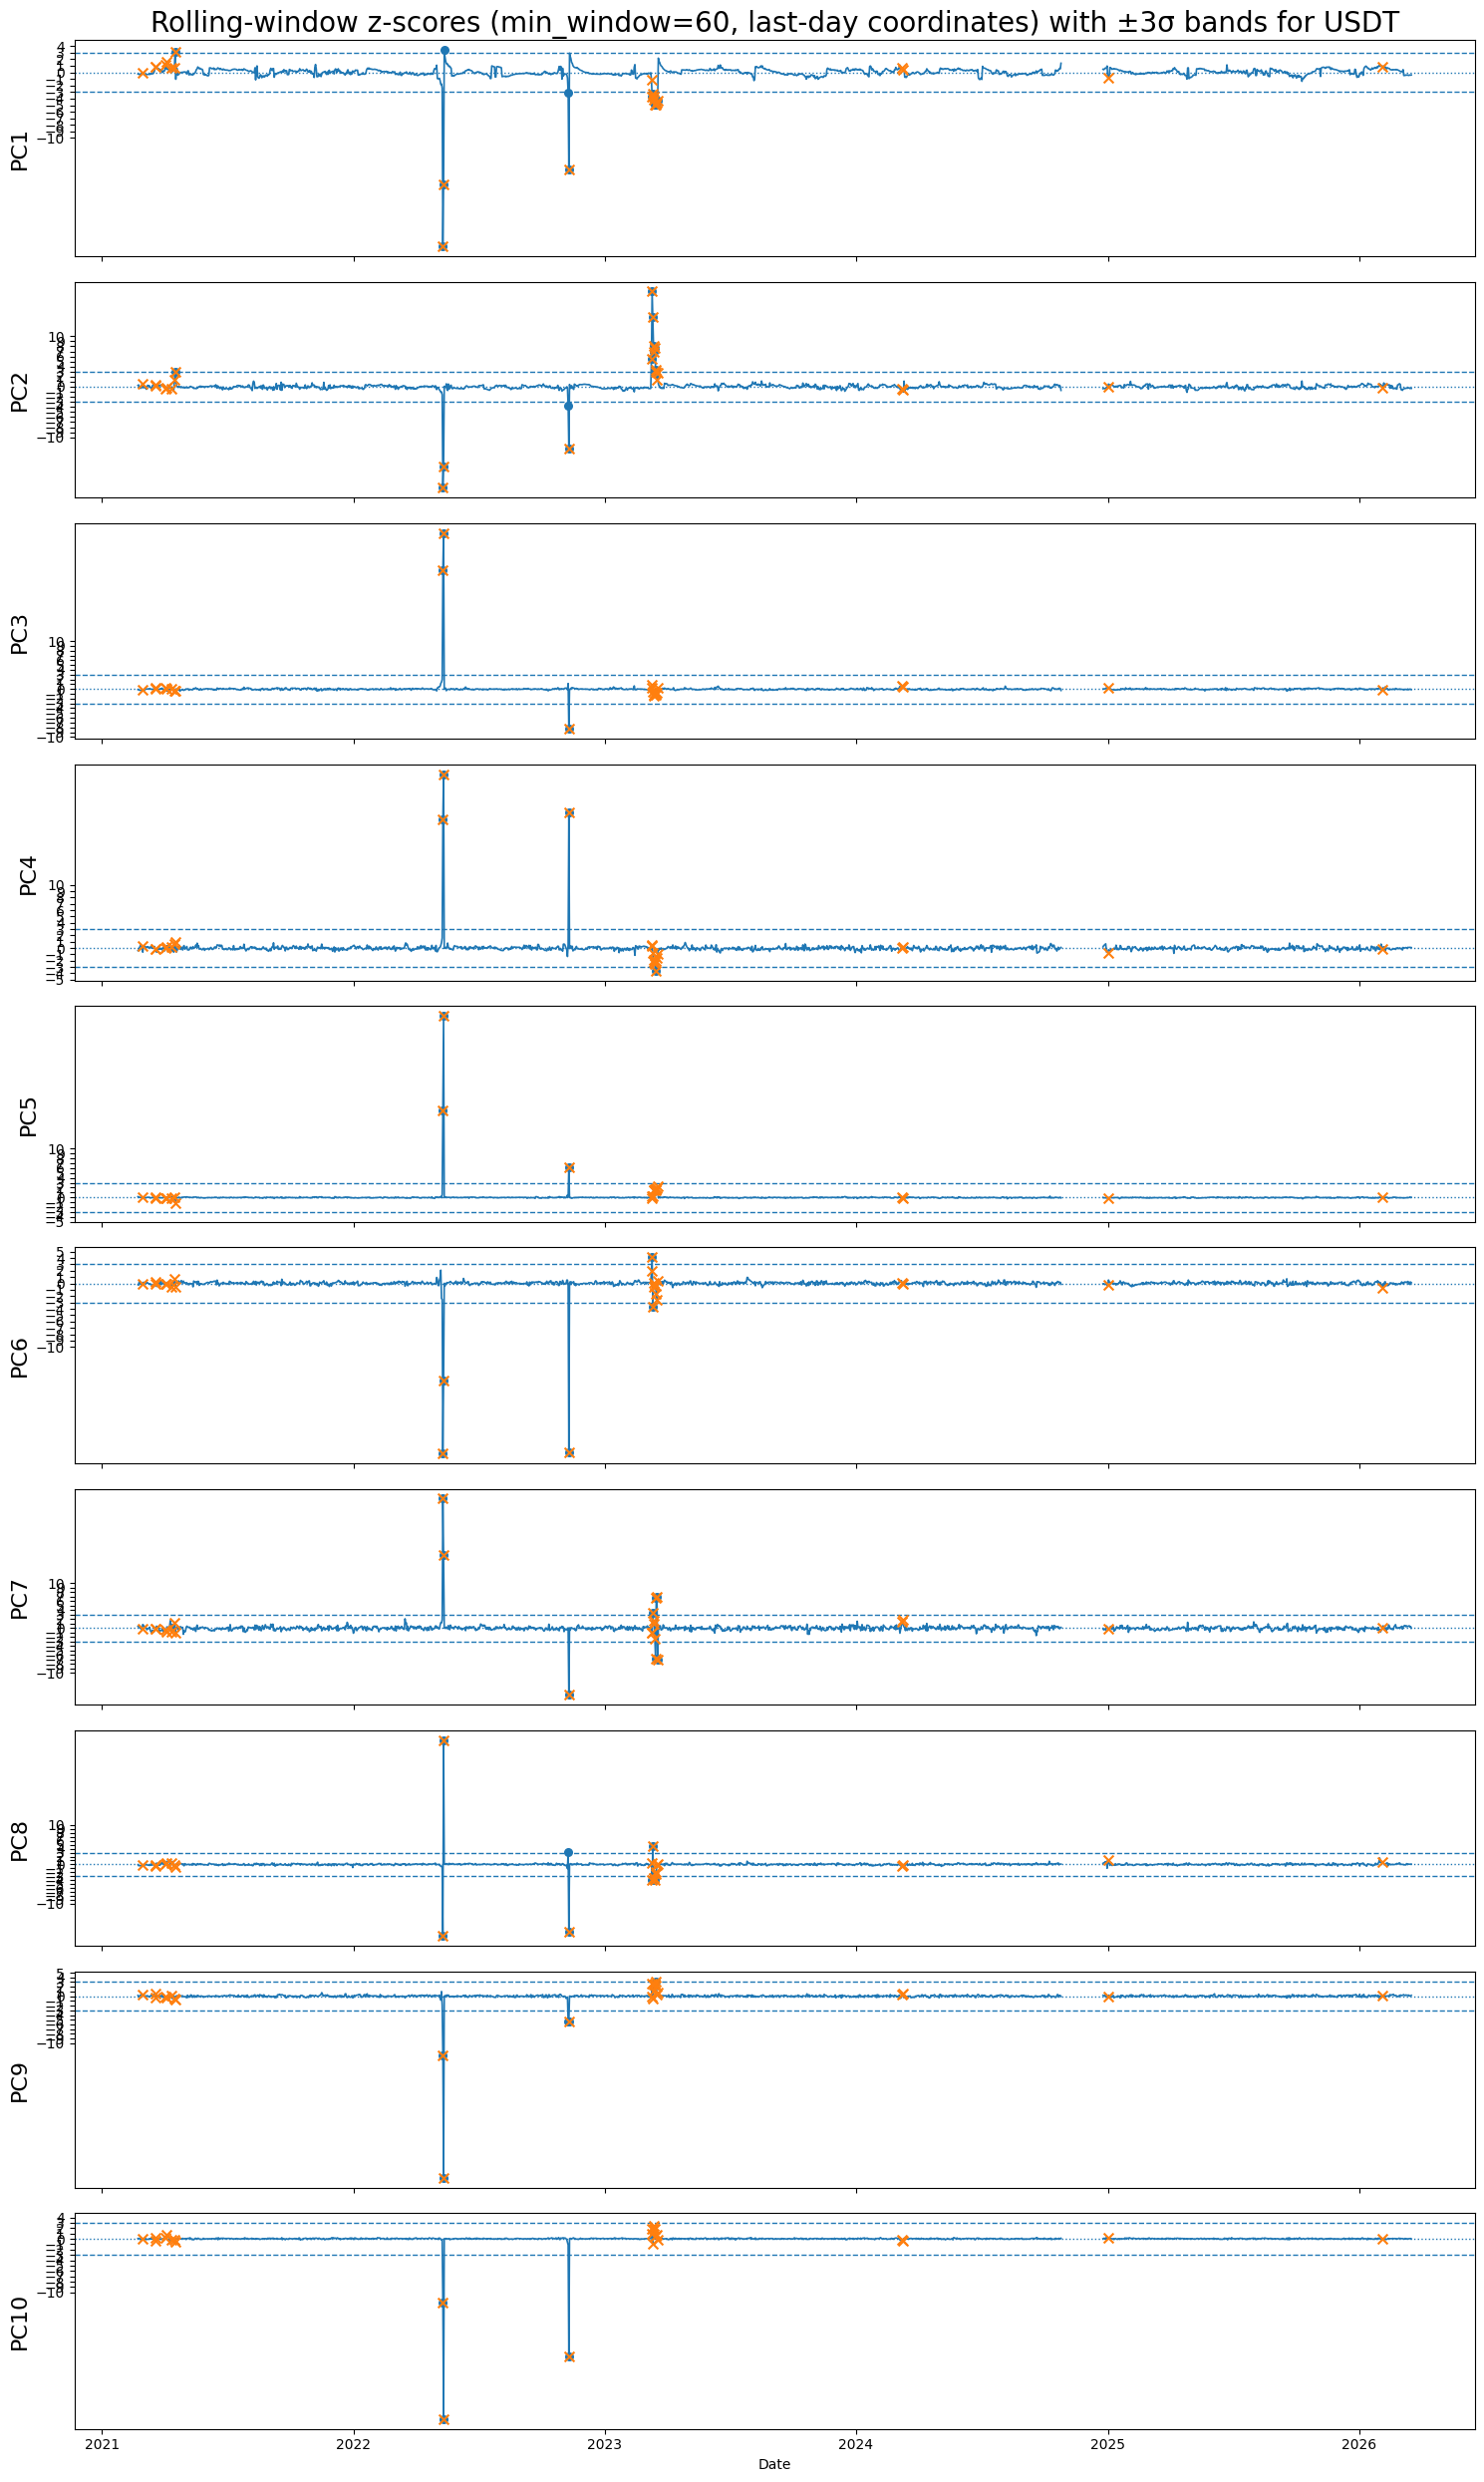

,PC,num_hit_days,num_real_depeg_days,num_matched_days,matched_depeg_days,first_match_days,avg_close_price_hit_days,avg_lead_time_matched,precision,recall,f1_score,specificity
0,PC2,13,28,10,"[2022-05-12 00:00:00, 2022-11-10 00:00:00, 202...","[2022-05-11 00:00:00, 2022-11-09 00:00:00, 202...",1.002681,1.0,0.769231,0.370370,0.500000,0.998359
1,PC1,15,28,10,"[2022-05-12 00:00:00, 2022-11-10 00:00:00, 202...","[2022-05-11 00:00:00, 2022-11-09 00:00:00, 202...",1.002359,1.0,0.666667,0.357143,0.465116,0.997266
2,PC8,9,28,7,"[2022-05-12 00:00:00, 2022-11-10 00:00:00, 202...","[2022-05-11 00:00:00, 2022-11-09 00:00:00, 202...",1.001758,1.0,0.777778,0.280000,0.411765,0.998905
3,PC7,8,28,5,"[2022-05-12 00:00:00, 2023-03-13 00:00:00, 202...","[2022-05-11 00:00:00, 2023-03-12 00:00:00, 202...",1.001034,1.0,0.625000,0.200000,0.303030,0.998360
4,PC6,5,28,3,"[2022-05-12 00:00:00, 2023-03-12 00:00:00, 202...","[2022-05-11 00:00:00, 2023-03-11 00:00:00, 202...",1.001231,1.0,0.600000,0.136364,0.222222,0.998906
5,PC9,5,28,3,"[2022-05-12 00:00:00, 2022-11-10 00:00:00, 202...","[2022-05-11 00:00:00, 2022-11-09 00:00:00, 202...",0.998410,1.0,0.600000,0.115385,0.193548,0.998905
6,PC4,4,28,2,"[2022-05-12 00:00:00, 2023-03-17 00:00:00]","[2022-05-11 00:00:00, 2023-03-16 00:00:00]",0.998363,1.0,0.500000,0.076923,0.133333,0.998906
7,PC3,3,28,1,[2022-05-12 00:00:00],[2022-05-11 00:00:00],0.997106,1.0,0.333333,0.035714,0.064516,0.998906
8,PC5,3,28,1,[2022-05-12 00:00:00],[2022-05-11 00:00:00],0.997106,1.0,0.333333,0.035714,0.064516,0.998906
9,PC10,3,28,1,[2022-05-12 00:00:00],[2022-05-11 00:00:00],0.997106,1.0,0.333333,0.035714,0.064516,0.998906


In [16]:
pc_cols = [f"PC{i}" for i in range(1, 11)]

df_usdt_final = pd.read_parquet("../clean_data/usdt_final.parquet")
df_usdt_pca = prepare_stablecoin_pca_df(df_usdt_final)
depeg_df_usdt = get_real_depeg_days(df_usdt_final)

pc_scores_usdt, loadings_dict_usdt = rolling_pca_scores_normal_only(
    df=df_usdt_pca,
    depeg_df=depeg_df_usdt,
    n_components=10,
    lead_days=7,
    min_normal_obs=10
)

# wanrings and hits
z_df_usdt = plot_pc_zscore_bands(pc_scores_usdt, baseline_end="2026-03-19", m = 3.0,
                     pc_cols=[f"PC{i}" for i in range(1, 11)])[0]

# effective warnings only: exclude same-day hits
hit_df_usdt = get_pc_hits_effective_only(
    z_df=z_df_usdt,
    m=3,
    original_df=df_usdt_final,
    depeg_df=depeg_df_usdt,
    pc_cols=pc_cols,
    max_lead_days=7
)

# Compare warnings with actual depeg days
plot_usdt = plot_pc_zscore_bands(
    z_df_usdt,
    m = 3,
    baseline_end="2026-03-19",
    pc_cols=[f"PC{i}" for i in range(1, 11)],
    hit_df=hit_df_usdt,
    depeg_df=depeg_df_usdt,
    plot_pc=True
)[1]

# matched PC profiles
matched_pc_profiles_usdt = extract_matched_pc_profiles(
    hit_df=hit_df_usdt,
    loadings_dict=loadings_dict_usdt,
    top_n=5
)

# recurring variable patterns
recurring_summary_usdt = summarize_recurring_pc_types(
    matched_pc_profiles_usdt,
    top_k_vars=3
)

summary_df_usdt = summarize_pc_hits(
    hit_df=hit_df_usdt,
    z_df=z_df_usdt,
    depeg_df=depeg_df_usdt,
    pc_cols=[f"PC{i}" for i in range(1, 11)],
    max_lead_days=7,
    include_no_lead_time=False
)
summary_df_usdt.head(10)

# For UST

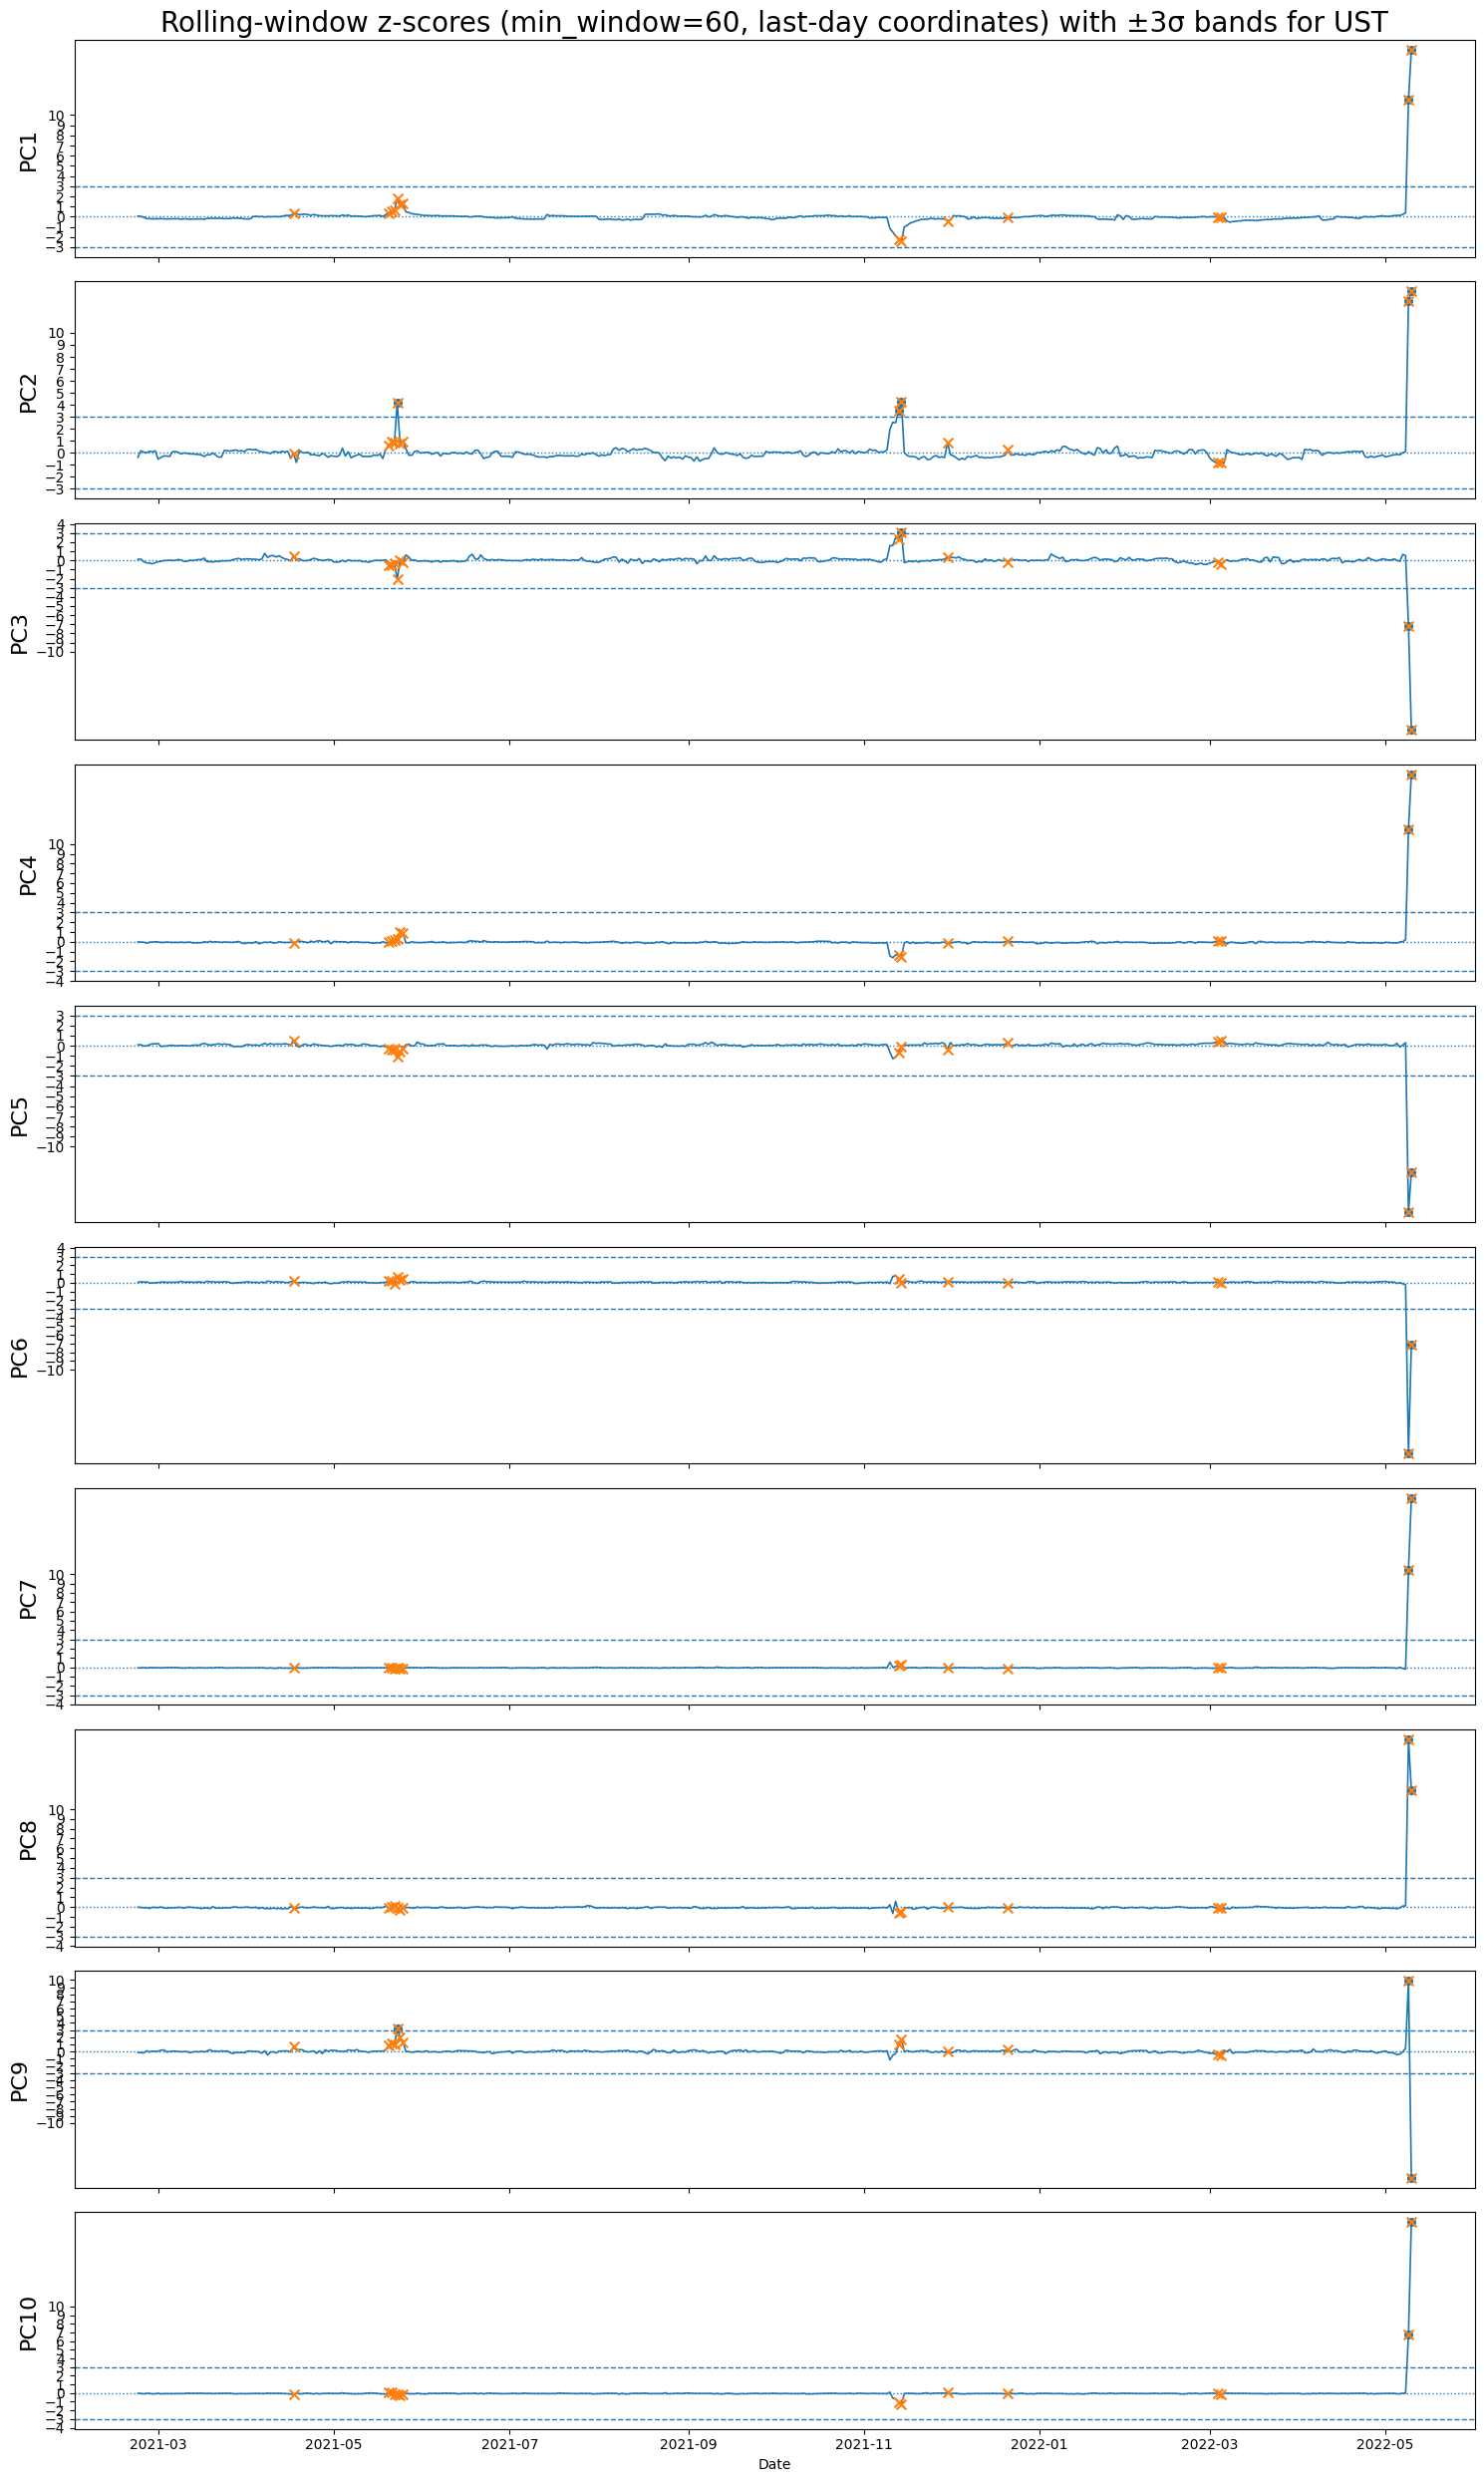

,PC,num_hit_days,num_real_depeg_days,num_matched_days,matched_depeg_days,first_match_days,avg_close_price_hit_days,avg_lead_time_matched,precision,recall,f1_score,specificity
0,PC2,5,33,3,"[2021-05-24 00:00:00, 2021-11-14 00:00:00, 202...","[2021-05-23 00:00:00, 2021-11-13 00:00:00, 202...",0.910692,1.0,0.600000,0.093750,0.162162,0.995349
1,PC9,3,33,2,"[2021-05-24 00:00:00, 2022-05-10 00:00:00]","[2021-05-23 00:00:00, 2022-05-09 00:00:00]",0.846335,1.0,0.666667,0.062500,0.114286,0.997669
2,PC1,2,33,1,[2022-05-10 00:00:00],[2022-05-09 00:00:00],0.796656,1.0,0.500000,0.030303,0.057143,0.997669
3,PC4,2,33,1,[2022-05-10 00:00:00],[2022-05-09 00:00:00],0.796656,1.0,0.500000,0.030303,0.057143,0.997669
4,PC5,2,33,1,[2022-05-10 00:00:00],[2022-05-09 00:00:00],0.796656,1.0,0.500000,0.030303,0.057143,0.997669
5,PC6,2,33,1,[2022-05-10 00:00:00],[2022-05-09 00:00:00],0.796656,1.0,0.500000,0.030303,0.057143,0.997669
6,PC7,2,33,1,[2022-05-10 00:00:00],[2022-05-09 00:00:00],0.796656,1.0,0.500000,0.030303,0.057143,0.997669
7,PC8,2,33,1,[2022-05-10 00:00:00],[2022-05-09 00:00:00],0.796656,1.0,0.500000,0.030303,0.057143,0.997669
8,PC10,2,33,1,[2022-05-10 00:00:00],[2022-05-09 00:00:00],0.796656,1.0,0.500000,0.030303,0.057143,0.997669
9,PC3,3,33,1,[2022-05-10 00:00:00],[2022-05-09 00:00:00],0.866680,1.0,0.333333,0.030303,0.055556,0.995349


In [17]:
pc_cols = [f"PC{i}" for i in range(1, 11)]

df_ust_final = pd.read_parquet("../clean_data/ust_final.parquet")
df_ust_pca = prepare_stablecoin_pca_df(df_ust_final)
depeg_df_ust = get_real_depeg_days(df_ust_final)

pc_scores_ust, loadings_dict_ust = rolling_pca_scores_normal_only(
    df=df_ust_pca,
    depeg_df=depeg_df_ust,
    n_components=10,
    lead_days=7,
    min_normal_obs=10
)

# wanrings and hits
z_df_ust = plot_pc_zscore_bands(pc_scores_ust, baseline_end="2026-03-19", m = 3.0,
                     pc_cols=[f"PC{i}" for i in range(1, 11)])[0]

# effective warnings only: exclude same-day hits
hit_df_ust = get_pc_hits_effective_only(
    z_df=z_df_ust,
    m=3,
    original_df=df_ust_final,
    depeg_df=depeg_df_ust,
    pc_cols=pc_cols,
    max_lead_days=7
)

# Compare warnings with actual depeg days
plot_ust = plot_pc_zscore_bands(
    z_df_ust,
    m = 3,
    baseline_end="2026-03-19",
    pc_cols=[f"PC{i}" for i in range(1, 11)],
    hit_df=hit_df_ust,
    depeg_df=depeg_df_ust,
    plot_pc=True
)[1]

# matched PC profiles
matched_pc_profiles_ust = extract_matched_pc_profiles(
    hit_df=hit_df_ust,
    loadings_dict=loadings_dict_ust,
    top_n=5
)

# recurring variable patterns
recurring_summary_ust = summarize_recurring_pc_types(
    matched_pc_profiles_ust,
    top_k_vars=3
)

summary_df_ust = summarize_pc_hits(
    hit_df=hit_df_ust,
    z_df=z_df_ust,
    depeg_df=depeg_df_ust,
    pc_cols=[f"PC{i}" for i in range(1, 11)],
    max_lead_days=7,
    include_no_lead_time=False
)
summary_df_ust.head(10)

# Summaries
## About hit days

In [ ]:
# output all plots
#plot_dai.savefig(f"rolling_{config_window}/dai_pc_zscore_bands_rolling{config_window}.png")
#plot_pax.savefig(f"rolling_{config_window}/pax_pc_zscore_bands_rolling{config_window}.png")
#plot_usdc.savefig(f"rolling_{config_window}/usdc_pc_zscore_bands_rolling{config_window}.png")
#plot_usdt.savefig(f"rolling_{config_window}/usdt_pc_zscore_bands_rolling{config_window}.png")
#plot_ust.savefig(f"rolling_{config_window}/ust_pc_zscore_bands_rolling{config_window}.png")

In [ ]:
# concat all summaries
summary_all = pd.concat([
    summary_df_dai.assign(stablecoin="DAI"),
    summary_df_pax.assign(stablecoin="PAX"),
    summary_df_usdc.assign(stablecoin="USDC"),
    summary_df_usdt.assign(stablecoin="USDT"),
    summary_df_ust.assign(stablecoin="UST")
], ignore_index=True)

summary_all['window'] = f'rolling{config_window}'

# reorder columns
summary_all = summary_all[[
    'window', 'stablecoin', 'PC', 'num_hit_days', 'num_real_depeg_days', 'num_matched_days',
    'avg_lead_time_matched', 'precision', 'recall', 'f1_score', 'specificity',
    'matched_depeg_days', 'first_match_days', 'avg_close_price_hit_days'
]]

#summary_all.to_csv(f"rolling_{config_window}/summary_PC_rolling{config_window}.csv", index=False)

In [ ]:
variable_summary_all = pd.concat([
    recurring_summary_dai.assign(stablecoin="DAI"),
    recurring_summary_pax.assign(stablecoin="PAX"),   
    recurring_summary_usdc.assign(stablecoin="USDC"),
    recurring_summary_usdt.assign(stablecoin="USDT"),
    recurring_summary_ust.assign(stablecoin="UST")
], ignore_index=True)

summary_all['window'] = f'rolling'
#variable_summary_all.to_csv(f"rolling_{config_window}/summary_variable_counts_rolling{config_window}.csv", index=False)


In [ ]:
# concat all hit details
hit_details_all = pd.concat([
    hit_df_dai.assign(stablecoin="DAI"),
    hit_df_pax.assign(stablecoin="PAX"),
    hit_df_usdc.assign(stablecoin="USDC"),    
    hit_df_usdt.assign(stablecoin="USDT"),
    hit_df_ust.assign(stablecoin="UST")
], ignore_index=True)

# reorder columns
hit_details_all = hit_details_all[[
    "stablecoin", "hit_date", "PC", "z_score", "close_price",
    "matched_depeg_date", "lead_time_days", "is_matched"
]]

#hit_details_all.to_csv(f"rolling_{config_window}/detailed_warnings_rolling{config_window}.csv", index=False)